### [__Making PR and ROC Plots__](https://plotly.com/python/roc-and-pr-curves/)
--- 
* y_true will be the STRING scores ≥ 400 (True positives)
    * Check with gold standard

* y_score will either
     * ipTM score will be used to determine this 
        * Will double check ipTM gold standard 

[__Precision Recall Curve__](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html)

Variable will be:
* precision
* recall
* thresholds
* pr_auc

[__Receiver Operating Characteristic__](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)

Varibles will be:
* fpr
* tpr
* thresholds
* auc_score

In [45]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go

In [46]:
## load csv `graph`
final_comp = pl.scan_csv("final_comp.csv")

thresholds = [400, 600, 800, 900]
score_expr = (
    pl.col("combined_score")
    .cast(pl.String)
    .str.replace_all(",", "", literal=True)
    .cast(pl.Float64, strict=False)
)
final_comp_sig = (
    final_comp
    .filter(pl.col("combined_score").is_not_null())
    .with_columns([
        (score_expr >= t).cast(pl.Int8).alias(f"gold_{t}")
        for t in thresholds
    ])
    .with_columns(
        y_score=score_expr / 1000
    )
)

df_evaluated = final_comp_sig.collect()

In [47]:
print(f"Number of avalibale edges of STRING scores that can be evaluated out of the total number of edges: {len(df_evaluated)}/{len(final_comp.collect())}")

Number of avalibale edges of STRING scores that can be evaluated out of the total number of edges: 102658/7568335


In [ ]:
print(final_comp_sig.collect().head())

print(f"Final number of edges being evaluated: {len(final_comp_sig.collect())}")

In [ ]:
# Setting up y_true and y_score
y_score = (
    df_evaluated
    .select(pl.col("chain_pair_iptm_mean_corrected"))
    .to_numpy()
    .flatten()
)

y_true = (
    df_evaluated
    .select(pl.col("gold_400").cast(pl.Int32, strict=False))
    .to_numpy()
    .flatten()
)

P = sum(y_true == 1)
N = sum(y_true == 0)

Precision Recall

In [ ]:
# %pip install plotly.express
import plotly.express as px
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

# Compute precision and recall arrays
precision, recall, thresholds = precision_recall_curve(y_true, y_score)
pr_auc = average_precision_score(y_true, y_score)


In [ ]:
#ploting interactive plot
fig = px.area(
    x=recall, y=precision,
    title=f'Precision-Recall Curve (AUC={auc(recall, precision):.4f})',
    labels=dict(x='Recall', y='Precision'),
    width=700, height=500
)
fig.add_hline(y=(P/(P+N)), line_dash="dash")
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_xaxes(constrain='domain')

fig.show()

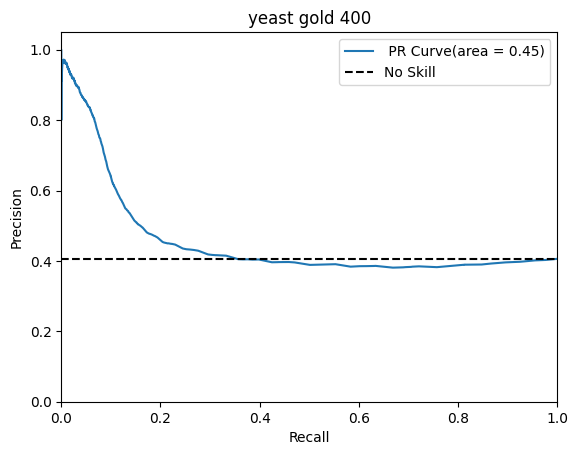

In [ ]:
# non-interactive plot
plt.figure()  
plt.plot(recall, precision, label=' PR Curve(area = %0.2f)' % pr_auc)
plt.axhline(y=(P/(P+N)), color='k', linestyle='--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('yeast gold 400')
plt.legend()
plt.show()

ROC

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc_score = roc_auc_score(y_true, y_score)
roc_auc = auc(fpr, tpr)

In [ ]:
#ploting interactive plot
fig = px.area(
    x=fpr, y=tpr,
    title=f'ROC Curve (AUC={auc(fpr, tpr):.4f})',
    labels=dict(x='False Positive Rate', y='True Positive Rate'),
    width=700, height=500
)
fig.add_shape(
    type='line', line=dict(dash='dash'),
    x0=0, x1=1, y0=0, y1=1
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_xaxes(constrain='domain')
fig.show()

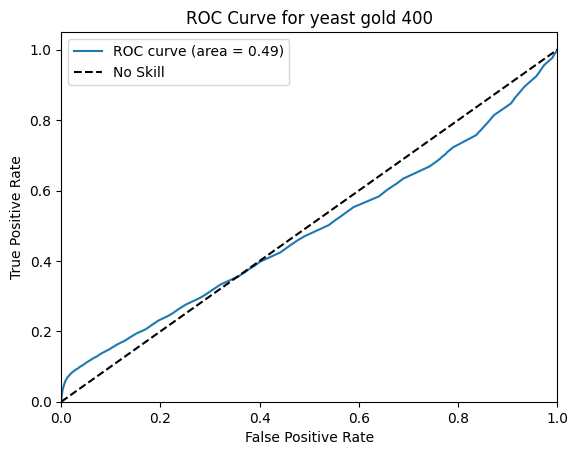

In [ ]:
#non interactive plot
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for yeast gold 400')
plt.legend()
plt.show()

Side-by-side comparrison

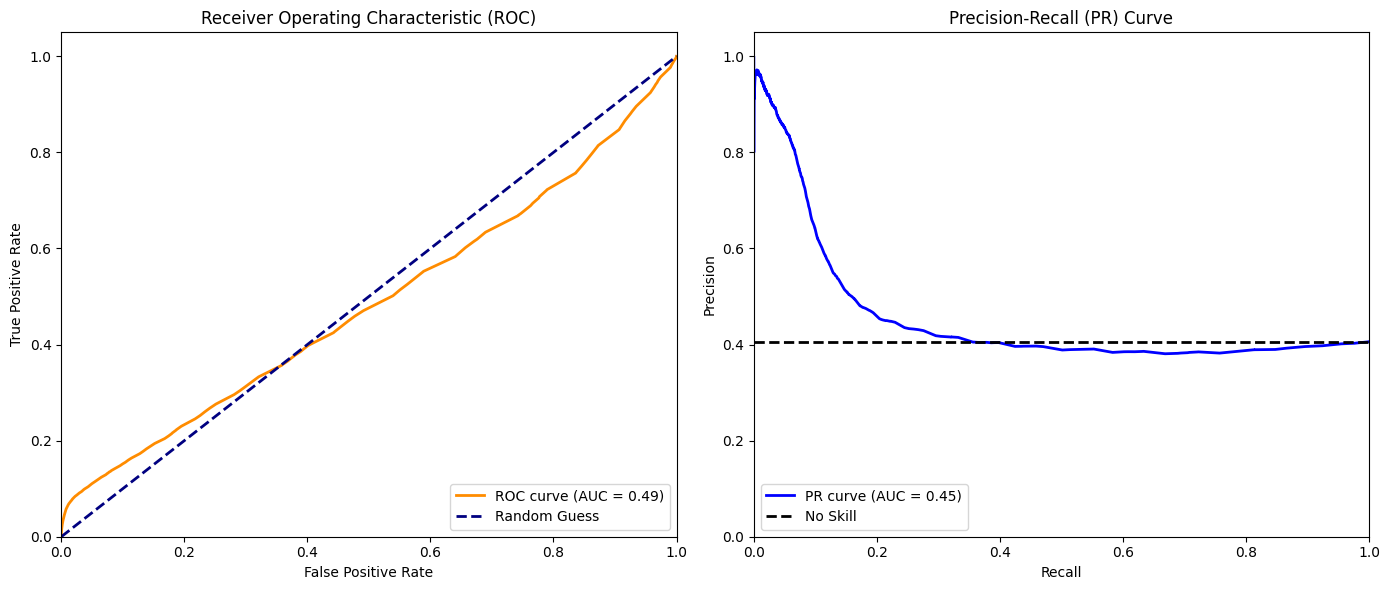

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve Plot
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")

# PR Curve Plot
ax2.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
ax2.axhline(y=(P/(P+N)), color='k', lw= 2, linestyle='--', label='No Skill')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall (PR) Curve')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

### __Interpertation of figures above__

__PR__:
With a heavily imbalanced dataset where positive cases are rare, the PR Area Under the Curve (AUC = 0.45) provides a conservative and highly realistic measure of performance, demonstrating that the model substantially outperforms a random baseline despite a sharp trade-off between minimizing false alarms and maximizing positive detections.

__ROC__:
There is an 49% chance that the model will rank a randomly chosen positive sample higher than a randomly chosen negative sample. 

Down below are all the scores for string gold standard.

In [ ]:
fig1 = go.Figure()
gold_columns = ["gold_400", "gold_600", "gold_800", "gold_900"]


for gold in gold_columns:
    y_true = df_evaluated[gold].cast(pl.Int32).to_numpy().flatten()
    
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)
    
    fig1.add_trace(go.Scatter(
        x=recall, 
        y=precision, 
        mode='lines',
        line=dict(width=2.5),
        name=f"{gold} (AUC = {pr_auc:.3f})"
    ))

fig1.add_trace(go.Scatter(
    x=[0, 1],          
    y=[(P/(P+N)), (P/(P+N))],    
    mode='lines',     
    name='No Skill Reference',
    showlegend=True,
    line=dict(color='black', width=2, dash='dash')
))

fig1.update_layout(
    title="Precision-Recall Curve Across All Gold Standards",
    xaxis_title="Recall",
    yaxis_title="Precision",
    xaxis=dict(range=[0, 1.01], gridcolor='rgba(255,255,255,0.8)'),
    yaxis=dict(range=[0, 1.01], gridcolor='rgba(255,255,255,0.8)'),
    plot_bgcolor='#ebf0f8', 
    width=700,
    height=600,
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99)
)

fig1.show()

In [ ]:
fig2 = go.Figure()
gold_columns = ["gold_400", "gold_600", "gold_800", "gold_900"]

fig2.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], 
    mode='lines', 
    line=dict(color='black', width=2, dash='dash'),
    name='Random Guess',
    showlegend=True
))

for gold in gold_columns:
    y_true = df_evaluated[gold].cast(pl.Int32).to_numpy().flatten()
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    fig2.add_trace(go.Scatter(
        x=fpr, 
        y=tpr, 
        mode='lines',
        line=dict(width=2.5),
        name=f"{gold} (AUC = {roc_auc:.3f})"
    ))
fig2.update_layout(
    title="ROC Across All Gold Standards",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    xaxis=dict(range=[0, 1.01], gridcolor='rgba(255,255,255,0.8)'),
    yaxis=dict(range=[0, 1.01], gridcolor='rgba(255,255,255,0.8)'),
    plot_bgcolor='#ebf0f8',  
    width=700,
    height=600,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.02)
)

fig2.show()

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 1. Initialize a figure with 1 row and 2 columns
fig = make_subplots(rows=1, cols=2)
for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    fig.add_trace(trace, row=1, col=2)

fig.update_layout(title_text="PR VS ROC Curve", 
                  height=600, 
                  width=1000, 
                  legend=dict())
# Display the combined figure
fig.show()